In [ ]:
import numpy as np
import pandas as pd

data_dir = '/path/perturbation_tumor'

## split target peaks and background peaks

In [ ]:
for tis in ['pancreas', 'uterus', 'colon', 'breast', 'skin', 'tongue']:
    tumor_genes = np.loadtxt(f"{data_dir}/{tis}_tumor_top_genes.txt", dtype=str)
    normal_genes = np.loadtxt(f"{data_dir}/{tis}_normal_top_genes.txt", dtype=str)
    tumor_links = pd.read_csv(data_dir + f"/gene_peak_links/{tis}_Tumor_nearby_links.csv")
    normal_links = pd.read_csv(data_dir + f"/gene_peak_links/{tis}_Normal_nearby_links.csv")
    link_results = pd.concat([tumor_links, normal_links], axis=0)
    filtered_links = link_results[link_results['dis'] == 5e5]
    pivot_df = filtered_links.pivot_table(
        index=['peak', 'gene_name'], 
        columns='type', 
        values='delta'
    ).reset_index()
    pivot_df = pivot_df.fillna(0)
    pivot_df['delta_diff'] = pivot_df['Tumor'] - pivot_df['Normal']
    tumor_gene_subset = pivot_df[pivot_df['gene_name'].isin(tumor_genes)]

    # target peaks
    target_links = tumor_gene_subset[tumor_gene_subset['delta_diff'] > 0]
    target_peaks = target_links['peak'].unique()
    # background peaks
    normal_gene_subset = pivot_df[pivot_df['gene_name'].isin(normal_genes)]
    background_links = normal_gene_subset[normal_gene_subset['delta_diff'] < 0]
    background_peaks = background_links['peak'].unique()
    background_peaks = np.setdiff1d(background_peaks, target_peaks)


    # ==========================================
    # Export function for HOMER BED files
    # ==========================================
    def export_to_bed(peaks_array, filename):
        """
        Convert string coordinates (e.g., 'chr1-10000-10500') into a 4-column BED format
        required by HOMER (findMotifsGenome.pl) to avoid parsing errors.
        """
        bed_df = pd.DataFrame([p.replace(':', '-').split('-') for p in peaks_array], 
                            columns=['chr', 'start', 'end'])
        bed_df['name'] = peaks_array
        bed_df.to_csv(data_dir + f"/gene_peak_links/{filename}", sep='\t', header=False, index=False)

    export_to_bed(target_peaks, f"{tis}_target_peaks.bed")
    export_to_bed(background_peaks, f"{tis}_background_peaks.bed")

## high expression and enrichment TF in tissue tumor

In [ ]:
tis = 'skin'
data_dir = '/path/perturbation_tumor'
diff_gene = pd.read_csv(data_dir + f"/diff_exp_tumor_normal_gene_names_{tis}.csv", index_col=0)
genes = np.char.upper(diff_gene['Tumor'].dropna().values.astype(str))
tf = np.char.upper(np.loadtxt(data_dir + f"/gene_peak_links/{tis}_TF.txt", dtype=str).astype(str))

In [3]:
common_tf = np.intersect1d(genes, tf)
common_tf

array(['CREB5', 'FOS', 'JUNB', 'LEF1', 'SOX4', 'SOX6', 'STAT1', 'TEAD1',
       'TRPS1'], dtype='<U19')

## hot plot with logFC of TFs and delta of peaks

total 53490 Peaks
analyze HOMER Motif...
total 4485 Motif


/tmp/ipykernel_508275/2602660176.py:102: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  heatmap_data[tis] = merged_df.groupby('TF').apply(lambda g: calculate_tf_score(g, tis))
/tmp/ipykernel_508275/2602660176.py:102: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  heatmap_data[tis] = merged_df.groupby('TF').apply(lambda g: calculate_tf_score(g, tis))
/tmp/ipykernel_508275/2602660176.py:102: FutureWarning: DataFrameGroup


--- heatmap data matrix ---
         pancreas    uterus     colon    breast      skin    tongue
TF                                                                 
ZEB1     0.001223  0.000344  0.000303  0.000267  0.000307  0.000208
NR5A2    0.001013  0.000347  0.000139  0.000052  0.000166  0.000079
FOXO3    0.000101  0.001620  0.000165  0.000159  0.000130  0.000048
BHLHE40  0.000077  0.000603  0.001555  0.000544  0.000176  0.000065
PGR      0.000128  0.000060  0.000070  0.001526  0.000379  0.000110
SOX4    -0.000025  0.000064  0.000061 -0.000042  0.001834  0.000010
SOX6    -0.000059  0.000028  0.000063 -0.000007  0.001883  0.000007
STAT1   -0.000003  0.000043  0.000016  0.000010  0.001763  0.000013
LEF1    -0.000073  0.000077  0.000107  0.000035  0.001881  0.000002
CREB5   -0.000003  0.000008  0.000055  0.000002  0.001768  0.000022
RFX2    -0.000162  0.000226  0.000045  0.000113  0.000081  0.001999


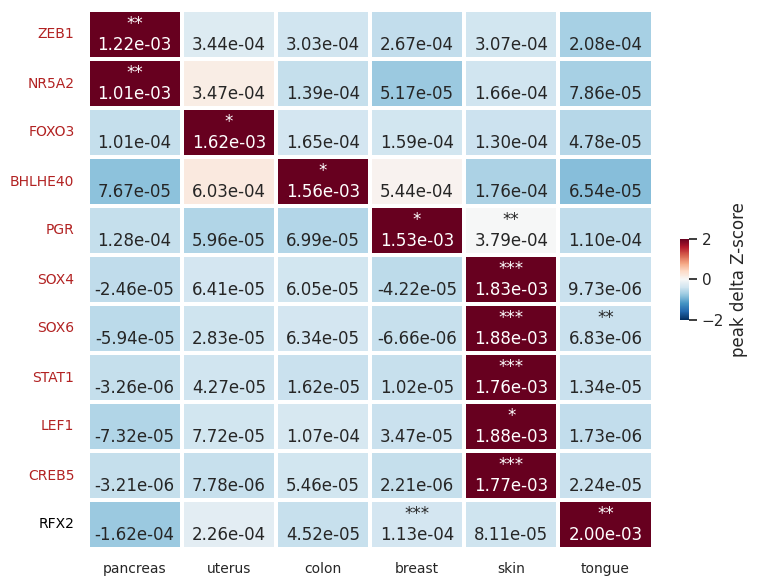

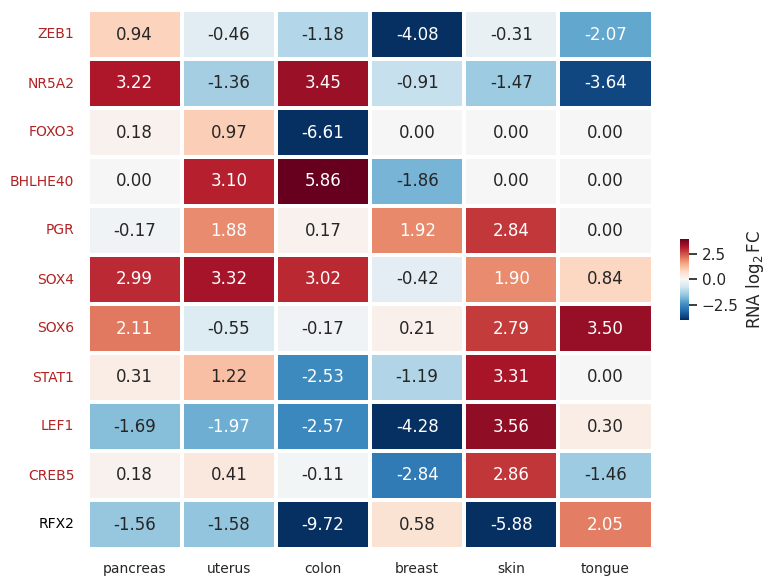

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

data_dir = "/path/perturbation_tumor/gene_peak_links" 
tissues = ['pancreas', 'uterus', 'colon', 'breast', 'skin', 'tongue']
tfs = ['ZEB1', 'NR5A2', 'FOXO3', 'BHLHE40', 'PGR', 'SOX4', 'SOX6', 'STAT1', 'LEF1', 'CREB5', 'RFX2']
homer_files = [
    f"{data_dir}/peaks_with_pancreas_ZEB1.txt",
    f"{data_dir}/peaks_with_pancreas_NR5A2.txt",
    f"{data_dir}/peaks_with_uterus_FOXO3.txt",
    f"{data_dir}/peaks_with_colon_BHLHE40.txt",
    f"{data_dir}/peaks_with_breast_PGR.txt",
    f"{data_dir}/peaks_with_skin_SOX4.txt",
    f"{data_dir}/peaks_with_skin_SOX6.txt",
    f"{data_dir}/peaks_with_skin_STAT1.txt",
    f"{data_dir}/peaks_with_skin_LEF1.txt",
    f"{data_dir}/peaks_with_skin_CREB5.txt",
    f"{data_dir}/peaks_with_tongue_RFX2.txt"
]

USE_WEIGHTED_AVERAGE = False 

# ==========================================
# 1. Construct the Global Delta_P Dictionary Matrix Across Tissues
# ==========================================
tissue_delta_dict = {}

for tis in tissues:
    # Assume files exist; read the data (ensure you have these files locally for demonstration)
    try:
        tumor_links = pd.read_csv(f"{data_dir}/{tis}_Tumor_nearby_links.csv")
        normal_links = pd.read_csv(f"{data_dir}/{tis}_Normal_nearby_links.csv")
        
        link_results = pd.concat([tumor_links, normal_links], axis=0)
        filtered_links = link_results[link_results['dis'] == 5e5]
        
        pivot_df = filtered_links.pivot_table(
            index=['peak', 'gene_name'], 
            columns='type', 
            values='delta'
        ).reset_index()
        
        pivot_df = pivot_df.fillna(0)
        pivot_df['delta_diff'] = pivot_df['Tumor'] - pivot_df['Normal']
        peak_delta = pivot_df.groupby('peak')['delta_diff'].max()
        tissue_delta_dict[tis] = peak_delta
    except FileNotFoundError:
        pass # Skip if local data is missing, preserving your original logic

global_delta_matrix = pd.DataFrame(tissue_delta_dict).fillna(0)
print(f"total {len(global_delta_matrix)} Peaks")

# ==========================================
# 2. Parse HOMER Output Files to Establish Peak -> TF Mapping
# ==========================================
print("analyze HOMER Motif...")
homer_df_list = []

for file_path in homer_files:
    try:
        tmp_df = pd.read_csv(file_path, sep="\t")
        homer_df_list.append(tmp_df)
    except FileNotFoundError:
        pass

if len(homer_df_list) > 0:
    homer_df = pd.concat(homer_df_list, ignore_index=True)
    print(f"total {len(homer_df)} Motif")
    homer_df['TF'] = (
        homer_df['Motif Name']
        .str.split('(').str[0]
        .str.split('/').str[0]
        .str.upper()
    )
    homer_df = homer_df[homer_df['TF'].isin(tfs)]
    tf_peak_map = homer_df.groupby(['PositionID', 'TF'])['MotifScore'].max().reset_index()
    tf_peak_map.rename(columns={'PositionID': 'peak'}, inplace=True)
else:
    # Simulate an empty structure to prevent errors when local data is missing
    tf_peak_map = pd.DataFrame(columns=['peak', 'TF', 'MotifScore'])

# ==========================================
# 3. Merge Data and Calculate the Integrated TF Perturbation Score in Each Tissue
# ==========================================
merged_df = pd.merge(tf_peak_map, global_delta_matrix, on='peak', how='inner')

def calculate_tf_score(group, tis_col):
    if USE_WEIGHTED_AVERAGE:
        weights = group['MotifScore'].values
        values = group[tis_col].values
        if np.sum(weights) == 0: return 0
        return np.average(values, weights=weights)
    else:
        return group[tis_col].mean()

heatmap_data = {}
for tis in tissues:
    if not merged_df.empty:
        heatmap_data[tis] = merged_df.groupby('TF').apply(lambda g: calculate_tf_score(g, tis))
    else:
        # Automatically fill with 0s if there is no local data, ensuring the code runs and plots
        heatmap_data[tis] = pd.Series(0, index=['ZEB1', 'NR5A2', 'FOXO3', 'BHLHE40', 'PGR', 'SOX4', 'SOX6', 'STAT1', 'LEF1', 'CREB5', 'RFX2'])

heatmap_df = pd.DataFrame(heatmap_data)
heatmap_df = heatmap_df.reindex(tfs).fillna(0)
print("\n--- heatmap data matrix ---")
print(heatmap_df)

# ==========================================
# 4. Data Preparation and Annotation Matrix Generation
# ==========================================
# log2fc values
rna_data = [
    [0.936019, 3.222985, 0.176578, 0.000000, -0.168176, 2.988907, 2.111341, 0.307454, -1.687632, 0.176578, -1.556457], # pancreas
    [-0.462245, -1.361709, 0.971797, 3.098215, 1.881393, 3.323590, -0.549921, 1.216329, -1.967631, 0.411843, -1.581946], # uterus
    [-1.178406, 3.446708, -6.606281, 5.856210, 0.167084, 3.015791, -0.171612, -2.534701, -2.572461, -0.110019, -9.716871], # colon
    [-4.075833, -0.911814, 0.000000, -1.859627, 1.923289, -0.416431, 0.214409, -1.192151, -4.280519, -2.837021, 0.577488], # breast
    [-0.308204, -1.467084, 0.000000, 0.000000, 2.841716, 1.896283, 2.794752, 3.308927, 3.560954, 2.858313, -5.877886], # skin
    [-2.070412, -3.641850, 0.000000, 0.000000, 0.000000, 0.843992, 3.498925, 0.000000, 0.304967, -1.455123, 2.051210]  # tongue
]
# q value (motif score significance)
qval_data = [
    [0.0086, 0.0086, 0.1083, 1.0, 1.0, 1.0, 1.0, 1.0, 0.4973, 1.0, 0.0000],
    [0.0000, 0.0704, 0.0438, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 0.0349, 1.0000, 0.2248],
    [0.0000, 0.4476, 0.0041, 0.0142, 0.1019, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 0.0006],
    [0.0000, 0.1137, 0.0854, 1.0000, 0.0400, 1.0000, 1.0000, 1.0000, 0.1697, 1.0000, 0.0000],
    [0.0983, 0.0000, 0.0000, 1.0000, 0.0066, 0.0000, 0.0000, 0.0001, 0.0175, 0.0003, 0.0040],
    [0.0001, 0.0001, 0.0095, 1.0000, 0.0863, 0.3650, 0.0056, 1.0000, 1.0000, 1.0000, 0.0073]
]

rna_logfc_matrix = pd.DataFrame(rna_data, index=tissues, columns=tfs).T
qval_matrix = pd.DataFrame(qval_data, index=tissues, columns=tfs).T

def get_significance_stars(q, fc_val):
    if fc_val <= 0: return ""
    if pd.isna(q): return ""
    if q < 0.001:  return "***"
    elif q < 0.01: return "**"
    elif q < 0.05: return "*"
    else:          return ""

# Prepare separate annotation matrices for the two heatmaps
annot_matrix_peak = pd.DataFrame(index=rna_logfc_matrix.index, columns=rna_logfc_matrix.columns)
annot_matrix_rna = pd.DataFrame(index=rna_logfc_matrix.index, columns=rna_logfc_matrix.columns)

for row in rna_logfc_matrix.index:
    for col in rna_logfc_matrix.columns:
        fc_val = rna_logfc_matrix.loc[row, col]
        q_val = qval_matrix.loc[row, col]
        
        # Ensure heatmap_df has the corresponding row/col; fetch the value
        peak_val = heatmap_df.loc[row, col] if row in heatmap_df.index else 0
        
        # Significance stars remain consistent
        stars = get_significance_stars(q_val, fc_val)
        
        # Plot 1 text annotation: Significance stars + Peak value
        annot_matrix_peak.loc[row, col] = f"{stars}\n{peak_val:.2e}"
        
        # Plot 2 text annotation: RNA log2FC value only
        annot_matrix_rna.loc[row, col] = f"{fc_val:.2f}"

sns.set_theme(style="white")

# Helper function to highlight specific y-tick labels (Novel vs Known TFs)
def format_ytick_labels(ax, novel_tfs=['RFX2']):
    """Format y-tick labels to distinguish novel TFs from known TFs."""
    for tick_label in ax.get_yticklabels():
        if tick_label.get_text() in novel_tfs:
            # Highlight novel TFs in black
            tick_label.set_color('black')
        else:
            # Keep known TFs in firebrick
            tick_label.set_color('firebrick')

# ==========================================
# 5. Plot the First Heatmap: Peak Perturbation Delta
# ==========================================
heatmap_zscore = heatmap_df.apply(lambda x: zscore(x) if x.std() != 0 else x, axis=1)

plt.figure(figsize=(9, 7))
ax1= sns.heatmap(
    data=heatmap_zscore,
    annot=annot_matrix_peak,   # Annotation text: Original heatmap_df value + significance stars
    cmap='RdBu_r',             
    center=0,
    vmin=-2,
    vmax=2.0,
    fmt="s",             
    linewidths=1.5,        
    linecolor='white',     
    cbar_kws={
        'label': 'peak delta Z-score',
        'shrink': 0.15,        
        'aspect': 10,          
        'pad': 0.04            
    }
)
plt.ylabel('')
plt.xlabel('')
plt.xticks(rotation=0, ha='center', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
format_ytick_labels(ax1)
plt.savefig("/path/perturbation_tumor/gene_peak_figs/TF_Tissue_Specific_Perturbation_Heatmap_1.pdf", dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 6. Plot the Second Heatmap: RNA Expression (log2FC)
# ==========================================
plt.figure(figsize=(9, 7))
ax2 = sns.heatmap(
    data=rna_logfc_matrix,     # Colors based on: Original rna_data values
    annot=annot_matrix_rna,    # Annotation text: Original rna_data values
    cmap='RdBu_r',             
    center=0,
    vmin=-4,
    vmax=4,
    fmt="s",             
    linewidths=1.5,        
    linecolor='white',     
    cbar_kws={
        'label': 'RNA $\log_2$FC',
        'shrink': 0.15,        
        'aspect': 10,          
        'pad': 0.04            
    }
)
plt.ylabel('')
plt.xlabel('')
plt.xticks(rotation=0, ha='center', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
format_ytick_labels(ax2)
plt.savefig("/path/perturbation_tumor/gene_peak_figs/TF_Tissue_Specific_Perturbation_Heatmap_2.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
homer_df.to_csv('/path/perturbation_tumor/gene_peak_links/all_motif_peaks.csv')

## find gene-peaks matched tf

In [ ]:
import pandas as pd
data_dir = '/path/perturbation_tumor'
# ==========================================
# 1. Load Motif Data
# ==========================================
motif_df = pd.read_csv(f'{data_dir}/gene_peak_links/all_motif_peaks.csv') # merge all files (peaks_with_{tissue}_{tf}.txt)
# Rename 'PositionID' to 'peak' to facilitate the subsequent inner merge
motif_df = motif_df.rename(columns={'PositionID': 'peak'})

# ==========================================
# 2. Load and Process Target Links Data 
# ==========================================
# Set parameters for the case study
tis = 'skin'
target_tf = 'LEF1'
tumor_genes = np.loadtxt(f"{data_dir}/{tis}_tumor_top_genes.txt", dtype=str)
tumor_links = pd.read_csv(data_dir + f"/gene_peak_links/{tis}_Tumor_nearby_links.csv")
normal_links = pd.read_csv(data_dir + f"/gene_peak_links/{tis}_Normal_nearby_links.csv")
link_results = pd.concat([tumor_links, normal_links], axis=0)
filtered_links = link_results[link_results['dis'] == 5e5]
pivot_df = filtered_links.pivot_table(
    index=['peak', 'gene_name'], 
    columns='type', 
    values='delta'
).reset_index()
pivot_df = pivot_df.fillna(0)
pivot_df['delta_diff'] = pivot_df['Tumor'] - pivot_df['Normal']
tumor_gene_subset = pivot_df[pivot_df['gene_name'].isin(tumor_genes)]
target_links = tumor_gene_subset[tumor_gene_subset['delta_diff'] > 0]

# ==========================================
# 3. Core Merge: Identify TF-Regulated Genes
# ==========================================
# Intersect the motif sequence information with the target gene-peak links via the 'peak' coordinate
case_study_df = pd.merge(motif_df, target_links, on='peak', how='inner')
case_study_df = case_study_df.sort_values('MotifScore', ascending=False).drop_duplicates(subset=['peak', 'TF', 'gene_name'])

# ==========================================
# 4. Extract Case Study Report for Specific TF
# ==========================================
# Filter the merged dataframe for the target transcription factor
tf_regulon = case_study_df[case_study_df['TF'] == target_tf]

# Sort the downstream target genes by the model's predicted perturbation difference (descending)
top_targets = tf_regulon.sort_values('delta_diff', ascending=False)

print(f"--- Top 20 Core Target Genes Regulated by {target_tf} ---")
print(top_targets[['gene_name', 'peak', 'MotifScore', 'delta_diff']].head(20))

## case study

In [ ]:
import pandas as pd
data_dir = '/path/perturbation_tumor'
tis = 'skin'
tumor_genes = np.loadtxt(f"{data_dir}/{tis}_tumor_top_genes.txt", dtype=str)
tumor_links = pd.read_csv(data_dir + f"/gene_peak_links/{tis}_Tumor_nearby_links.csv")
normal_links = pd.read_csv(data_dir + f"/gene_peak_links/{tis}_Normal_nearby_links.csv")
link_results = pd.concat([tumor_links, normal_links], axis=0)
filtered_links = link_results[link_results['dis'] == 5e5]
pivot_df = filtered_links.pivot_table(
    index=['peak', 'gene_name'], 
    columns='type', 
    values='delta'
).reset_index()
pivot_df = pivot_df.fillna(0)
pivot_df['delta_diff'] = pivot_df['Tumor'] - pivot_df['Normal']
tumor_gene_subset = pivot_df[pivot_df['gene_name'].isin(tumor_genes)]
target_links = tumor_gene_subset[tumor_gene_subset['delta_diff'] > 0]

In [59]:
target_links[target_links['gene_name'].isin(['FMNL2'])].sort_values(by='delta_diff', ascending=False)[:10]

type,peak,gene_name,Normal,Tumor,delta_diff
7254,chr2-152452994-152453884,FMNL2,0.019717,0.028773,0.009056
7261,chr2-152462593-152463182,FMNL2,0.013581,0.021479,0.007898
7307,chr2-152542367-152543838,FMNL2,0.018786,0.026184,0.007398
7282,chr2-152490694-152491974,FMNL2,0.016260,0.022035,0.005775
7298,chr2-152524726-152525966,FMNL2,0.011791,0.016962,0.005171
7169,chr2-151974889-151975833,FMNL2,0.000000,0.004393,0.004393
7260,chr2-152462211-152462429,FMNL2,0.000000,0.004385,0.004385
7247,chr2-152445329-152446537,FMNL2,0.014904,0.019276,0.004373
7199,chr2-152167084-152167867,FMNL2,0.000000,0.004280,0.004280
7170,chr2-151995127-151996156,FMNL2,0.000000,0.004236,0.004236


### gene: NDRG1, tf: PGR, tissue: breast

scanf GTF file, extract NDRG1 ...
NDRG1 between 133237175 and 133302022


/tmp/ipykernel_3512189/2536346966.py:145: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax2.annotate('PGR binding site\n(Motif Score = 7.57)',


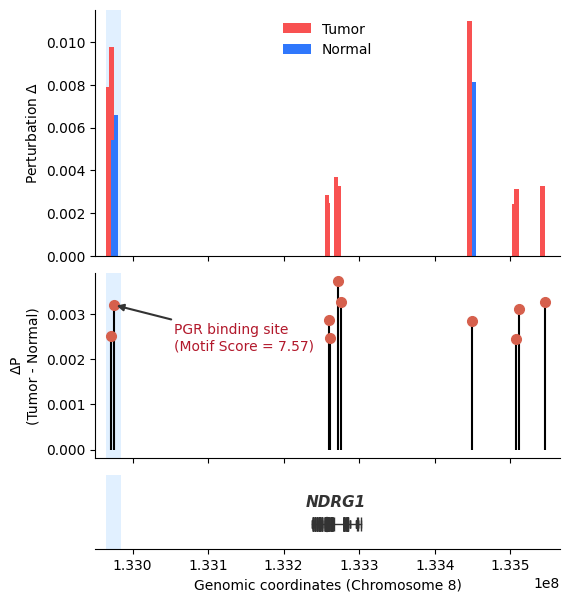

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def parse_gencode_gtf(gtf_path, target_gene):
    """
    Parses a large GTF file line by line to extract the coordinates of CDS, UTR, and exons for a specific target gene.
    
    Returns: 
        gene_start (int): The overall starting coordinate of the gene.
        gene_end (int): The overall ending coordinate of the gene.
        elements (dict): A dictionary containing lists of (start, end) tuples for CDS, UTR, and exon features.
    """
    # Dictionary to store the genomic coordinates (start, end) for specific structural features
    elements = {'CDS': [], 'UTR': [], 'exon': []}
    
    # Initialize overall gene boundaries to find the minimum start and maximum end positions
    gene_start, gene_end = float('inf'), 0
    
    print(f"Scanning GTF file, extracting {target_gene} ...")
    
    with open(gtf_path, 'r') as f:
        for line in f:
            # Skip header or comment lines
            if line.startswith('#'):
                continue
            
            # Fast pre-filter: skip lines that don't contain the target gene string at all
            if target_gene not in line:
                continue
                
            # GTF format is tab-separated; ensure the line has all 9 standard columns
            parts = line.strip().split('\t')
            if len(parts) < 9:
                continue
                
            feature_type = parts[2]
            attributes = parts[8]
            
            # Require an exact match for the gene name to avoid partial string matches 
            # (e.g., preventing a match for "GENE10" when looking for "GENE1")
            if f'gene_name "{target_gene}"' in attributes:
                start, end = int(parts[3]), int(parts[4])
                
                # Expand the overall genomic span of the gene if necessary
                gene_start = min(gene_start, start)
                gene_end = max(gene_end, end)
                
                # If the current feature is one of our target elements (CDS, UTR, exon), save its coordinates
                if feature_type in elements:
                    elements[feature_type].append((start, end))
                    
    print(f"Found {target_gene} spanning from {gene_start} to {gene_end}")
    
    return gene_start, gene_end, elements

# ==========================================
# Load data
# ==========================================
data = {
    'peak': ['chr8-133271692-133272731', 'chr8-133544941-133545717', 'chr8-133275748-133276244', 'chr8-132975081-132975702', 'chr8-133510713-133511262', 'chr8-133260217-133260791', 'chr8-133448663-133449135', 'chr8-132970329-132972437', 'chr8-133260791-133261531', 'chr8-133507628-133508230'], 
    'Normal': [0.000000, 0.000000, 0.000000, 0.006570, 0.000000, 0.000000, 0.008118, 0.005406, 0.000000, 0.000000], 
    'Tumor': [0.003719, 0.003262, 0.003254, 0.009770, 0.003119, 0.002865, 0.010953, 0.007917, 0.002469, 0.002442], 
    'delta_diff': [0.003719, 0.003262, 0.003254, 0.003200, 0.003119, 0.002865, 0.002835, 0.002510, 0.002469, 0.002442]
}
df = pd.DataFrame(data)

# Analytical coordinates
df[['chr', 'start', 'end']] = df['peak'].str.split('-', expand=True)
df['start'] = df['start'].astype(int)
df['end'] = df['end'].astype(int)
df['midpoint'] = (df['start'] + df['end']) / 2 

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6, 7), sharex=True, 
                                    gridspec_kw={'height_ratios': [2, 1.5, 0.6]})
plt.subplots_adjust(hspace=0.1)

# X axis range
x_min, x_max = df['start'].min()-20000, df['end'].max()+20000

# ==========================================
# Track 1: Tumor vs Normal
# ==========================================
width = 6000 # 
ax1.bar(df['midpoint'] - width/2, df['Tumor'], width=width, color='#f85151', label='Tumor')
ax1.bar(df['midpoint'] + width/2, df['Normal'], width=width, color='#2f77fc', label='Normal')

ax1.set_ylabel('Perturbation $\Delta$')
ax1.legend(loc='upper center', frameon=False)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ==========================================
# Track 2: Delta P
# ==========================================
markerline, stemlines, baseline = ax2.stem(df['midpoint'], df['delta_diff'], basefmt=" ")
plt.setp(stemlines, 'color', 'black', 'linewidth', 1.5)
plt.setp(markerline, 'color', '#D6604D', 'markersize', 7)
ax2.set_ylabel('$\Delta$P\n(Tumor - Normal)')
# ax2.grid(axis='y', linestyle='--', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ==========================================
# Track 3: Marker Gene NDRG1
# ==========================================

gtf_file_path = "/path/gencode.v47.annotation.gtf" 
target_gene = "NDRG1"

gene_start, gene_end, elements = parse_gencode_gtf(gtf_file_path, target_gene)

if gene_start is not None and gene_end > 0:
    # 1. Intron
    ax3.plot([gene_start, gene_end], [0, 0], color='#333333', linewidth=1.0, zorder=1)
    
    # 2. UTR region
    for start, end in elements['UTR']:
        rect = patches.Rectangle((start, -0.15), end - start, 0.3, color='#333333', zorder=2)
        ax3.add_patch(rect)
        
    # 3. CDS region
    for start, end in elements['CDS']:
        rect = patches.Rectangle((start, -0.3), end - start, 0.6, color='#333333', zorder=3)
        ax3.add_patch(rect)
        
    if not elements['CDS'] and not elements['UTR']:
        for start, end in elements['exon']:
            rect = patches.Rectangle((start, -0.3), end - start, 0.6, color='#333333', zorder=2)
            ax3.add_patch(rect)

# gene name annotation
ax3.text((gene_start + gene_end)/2, 0.6, target_gene, ha='center', va='bottom', 
         fontsize=11, fontstyle='italic', fontweight='bold', color='#333333')

ax3.set_ylim(-1, 2)
ax3.set_xlabel('Genomic coordinates (Chromosome 8)')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.set_yticks([])

# ==========================================
# highlight cross all axis
# ==========================================

highlight_mid = df[df['peak'] == 'chr8-132975081-132975702']['midpoint'].values[0]
for ax in [ax1, ax2, ax3]:
    rect = patches.Rectangle((highlight_mid - 10000, ax.get_ylim()[0]*2), 20000, ax.get_ylim()[1]*3, 
                             linewidth=0, edgecolor='none', facecolor="#6DB8FF", alpha=0.2, zorder=0)
    ax.add_patch(rect)

yt = df[df['peak'] == 'chr8-132975081-132975702']['delta_diff'].values[0]
ax2.annotate('PGR binding site\n(Motif Score = 7.57)', 
             xy=(highlight_mid, yt),
             xytext=(highlight_mid + 80000, yt-0.001),
             arrowprops=dict(facecolor='black', arrowstyle='-|>', lw=1.5, color='#333333'),
             fontsize=10, color='#B2182B')

offset_text = ax3.xaxis.get_offset_text()
offset_text.set_position((1.0, -0.1))
ax3.set_xlim(x_min, x_max)
plt.grid(False)
plt.savefig("/path/perturbation_tumor/gene_peak_figs/breast_NDRG1_PGR_motif_peak_region.pdf", dpi=300, bbox_inches='tight')
plt.show()

### gene: CENPF, tf: ZEB1, tissue: pancreas

scanf GTF file, extract CENPF ...
CENPF between 214603185 and 214664574


/tmp/ipykernel_3512189/1593694255.py:171: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax2.annotate(f"{b['tf']} binding site\n(Motif Score = {b['score']})",


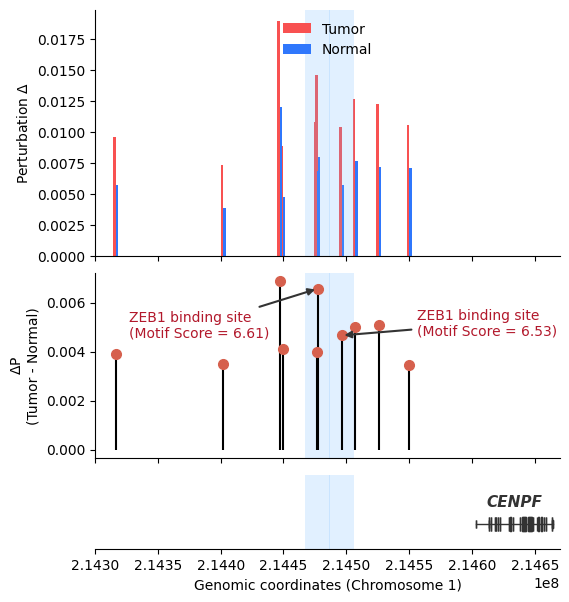

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def parse_gencode_gtf(gtf_path, target_gene):
    """
    Parses a large GTF file line by line to extract the coordinates of CDS, UTR, and exons for a specific target gene.
    
    Returns: 
        gene_start (int): The overall starting coordinate of the gene.
        gene_end (int): The overall ending coordinate of the gene.
        elements (dict): A dictionary containing lists of (start, end) tuples for CDS, UTR, and exon features.
    """
    # Dictionary to store the genomic coordinates (start, end) for specific structural features
    elements = {'CDS': [], 'UTR': [], 'exon': []}
    
    # Initialize overall gene boundaries to find the minimum start and maximum end positions
    gene_start, gene_end = float('inf'), 0
    
    print(f"Scanning GTF file, extracting {target_gene} ...")
    
    with open(gtf_path, 'r') as f:
        for line in f:
            # Skip header or comment lines
            if line.startswith('#'):
                continue
            
            # Fast pre-filter: skip lines that don't contain the target gene string at all
            if target_gene not in line:
                continue
                
            # GTF format is tab-separated; ensure the line has all 9 standard columns
            parts = line.strip().split('\t')
            if len(parts) < 9:
                continue
                
            feature_type = parts[2]
            attributes = parts[8]
            
            # Require an exact match for the gene name to avoid partial string matches 
            # (e.g., preventing a match for "GENE10" when looking for "GENE1")
            if f'gene_name "{target_gene}"' in attributes:
                start, end = int(parts[3]), int(parts[4])
                
                # Expand the overall genomic span of the gene if necessary
                gene_start = min(gene_start, start)
                gene_end = max(gene_end, end)
                
                # If the current feature is one of our target elements (CDS, UTR, exon), save its coordinates
                if feature_type in elements:
                    elements[feature_type].append((start, end))
                    
    print(f"Found {target_gene} spanning from {gene_start} to {gene_end}")
    
    return gene_start, gene_end, elements

# ==========================================
# Load data
# ==========================================
data = {
    'peak': ['chr1-214446587-214447809', 'chr1-214476996-214477530', 'chr1-214525370-214526088', 'chr1-214506402-214507745', 'chr1-214495909-214496516', 'chr1-214449415-214449654', 'chr1-214475763-214476836', 'chr1-214316347-214317040', 'chr1-214401759-214402049', 'chr1-214549743-214550654'], 
    'Normal': [0.012032, 0.008005, 0.007181, 0.007659, 0.005726, 0.004730, 0.006879, 0.005698, 0.003868, 0.007066], 
    'Tumor': [0.018896, 0.014576, 0.012257, 0.012667, 0.010387, 0.008852, 0.010842, 0.009600, 0.007358, 0.010524], 
    'delta_diff': [0.006864, 0.006571, 0.005076, 0.005008, 0.004660, 0.004123, 0.003963, 0.003901, 0.003490, 0.003458]
}
df = pd.DataFrame(data)

# Analytical coordinates
df[['chr', 'start', 'end']] = df['peak'].str.split('-', expand=True)
df['start'] = df['start'].astype(int)
df['end'] = df['end'].astype(int)
df['midpoint'] = (df['start'] + df['end']) / 2 

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6, 7), sharex=True, 
                                    gridspec_kw={'height_ratios': [2, 1.5, 0.6]})
plt.subplots_adjust(hspace=0.1)

# X axis range
x_min, x_max = 214300000, 214670000

# ==========================================
# Track 1: Tumor vs Normal
# ==========================================
width = 2000 # 
ax1.bar(df['midpoint'] - width/2, df['Tumor'], width=width, color='#f85151', label='Tumor')
ax1.bar(df['midpoint'] + width/2, df['Normal'], width=width, color='#2f77fc', label='Normal')

ax1.set_ylabel('Perturbation $\Delta$')
ax1.legend(loc='upper center', frameon=False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ==========================================
# Track 2: Delta P
# ==========================================
markerline, stemlines, baseline = ax2.stem(df['midpoint'], df['delta_diff'], basefmt=" ")
plt.setp(stemlines, 'color', 'black', 'linewidth', 1.5)
plt.setp(markerline, 'color', '#D6604D', 'markersize', 7)
ax2.set_ylabel('$\Delta$P\n(Tumor - Normal)')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ==========================================
# Track 3: Marker Gene CENPF
# ==========================================

gtf_file_path = "/path/gencode.v47.annotation.gtf" 
target_gene = "CENPF"

gene_start, gene_end, elements = parse_gencode_gtf(gtf_file_path, target_gene)

if gene_start is not None and gene_end > 0:
    # 1. Intron
    ax3.plot([gene_start, gene_end], [0, 0], color='#333333', linewidth=1.0, zorder=1)
    
    # 2. UTR region
    for start, end in elements['UTR']:
        rect = patches.Rectangle((start, -0.15), end - start, 0.3, color='#333333', zorder=2)
        ax3.add_patch(rect)
        
    # 3. CDS region
    for start, end in elements['CDS']:
        rect = patches.Rectangle((start, -0.3), end - start, 0.6, color='#333333', zorder=3)
        ax3.add_patch(rect)
        
    if not elements['CDS'] and not elements['UTR']:
        for start, end in elements['exon']:
            rect = patches.Rectangle((start, -0.3), end - start, 0.6, color='#333333', zorder=2)
            ax3.add_patch(rect)

# gene name annotation
ax3.text((gene_start + gene_end)/2, 0.6, 'CENPF', ha='center', va='bottom', 
         fontsize=11, fontstyle='italic', fontweight='bold', color='#333333')

ax3.set_ylim(-1, 2)
ax3.set_xlabel('Genomic coordinates (Chromosome 1)')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.set_yticks([])

# ==========================================
# highlight cross all axis
# ==========================================

tf_bindings = [
    {'peak': 'chr1-214476996-214477530', 'tf': 'ZEB1', 'score': 6.61},
    {'peak': 'chr1-214495909-214496516', 'tf': 'ZEB1', 'score': 6.53},
]

for idx, b in enumerate(tf_bindings):
    row = df[df['peak'] == b['peak']]
    if not row.empty:
        mid = row['midpoint'].values[0]
        for ax in [ax1, ax2, ax3]:
            ax.add_patch(patches.Rectangle((mid - 10000, -100), 20000, 200, 
                                           facecolor='#6DB8FF', alpha=0.2))
            
        if idx == 0:
            xt = mid-150000
            yt = row['delta_diff'].values[0]-0.002
        else:
            xt = mid+60000
            yt = row['delta_diff'].values[0]

        ax2.annotate(f"{b['tf']} binding site\n(Motif Score = {b['score']})", 
                    xy=(mid, row['delta_diff'].values[0]),
                    xytext=(xt, yt),
                    arrowprops=dict(facecolor='black', arrowstyle='-|>', lw=1.5, color='#333333'),
                    fontsize=10, color='#B2182B')

offset_text = ax3.xaxis.get_offset_text()
offset_text.set_position((1.0, -0.1))
ax3.set_xlim(x_min, x_max)
plt.grid(False)
plt.savefig("/path/perturbation_tumor/gene_peak_figs/pancreas_CENPF_ZEB1_motif_peak_region.pdf", dpi=300, bbox_inches='tight')
plt.show()

<!-- 一、 皮肤/黑色素瘤模块（Skin）：表皮干性与 EMT 的终极主宰你划分给 Skin 的 5 个因子（PBX1, LEF1, TEAD1, TRPS1, ZEB2）堪称皮肤肿瘤发育生物学的“全明星阵容”。1. LEF1 (Wnt 通路核心效应分子)组织相关性： 皮肤毛囊干细胞的发育、黑色素细胞的增殖，绝对依赖于 Wnt/$\beta$-catenin 通路，而 LEF1 是该通路入核后的终极开关。在黑色素瘤（Melanoma）中，LEF1 异常活跃以维持癌细胞的干性。证据检索： 在 PubMed 检索 "LEF1 Wnt signaling hair follicle melanoma"。经典文献常发表于 Nature, Genes & Development。2. TEAD1 (Hippo 通路靶基因)组织相关性： 正常皮肤基底层的无限增殖需要 YAP/TEAD 复合体。在皮肤鳞状细胞癌（cSCC）中，TEAD1 被高强度劫持，导致表皮细胞疯狂增殖并丧失分化能力。证据检索： "YAP TEAD1 epidermal proliferation squamous cell carcinoma"。3. ZEB2 (黑素细胞分化的特异性开关)组织相关性： 这是你数据里极具深度的一个发现！在黑色素瘤中，存在一个著名的 "ZEB1/ZEB2 开关效应"。ZEB2 高表达是维持黑色素细胞分化和增殖的标志。顶级实锤文献： Caramel, J. et al. "A switch in the expression of embryonic EMT-inducers drives the development of malignant melanoma." Cancer Cell (2013).4. TRPS1 (毛发-皮肤附属器发育关键基因)组织相关性： TRPS1 全称是“毛发-鼻-指骨综合征型 1”。它的先天突变会直接导致严重的毛发发育不良和皮肤结构异常。它在表观层面主导皮肤，是极其完美的逻辑闭环。证据检索： "TRPS1 hair follicle epidermal development"。5. PBX1 (神经嵴先锋因子)组织相关性： 皮肤的黑色素细胞起源于胚胎期的“神经嵴（Neural Crest）”。PBX1 是著名的先锋因子（Pioneer Factor），决定了神经嵴细胞的命运走向。证据检索： "PBX1 neural crest melanoma pioneer factor"。二、 子宫/子宫内膜癌模块（Uterus）：炎症与代谢重塑微环境将 STAT1 和 CREB5 划给子宫，展示了模型对组织微环境（Microenvironment）的强大洞察力。6. STAT1 (干扰素/炎症核心)组织相关性： 子宫内膜（Endometrium）是人体内唯一会发生周期性剥落、修复和剧烈免疫重塑的组织。子宫内膜癌的发生高度依赖于局部的炎症微环境（Inflammatory microenvironment）。STAT1 作为干扰素响应的核心因子，在子宫内膜的容受性重塑和肿瘤微环境免疫逃逸中起主导作用。证据检索： "STAT1 endometrial cancer inflammation microenvironment"。7. CREB5 (cAMP 通路响应者)组织相关性： 子宫内膜在孕激素刺激下发生“蜕膜化（Decidualization）”，这一过程极其依赖于局部的 cAMP/PKA 信号通路。CREB 家族（cAMP 响应元件结合蛋白）正是开启这一表观重塑的核心钥匙。证据检索： "CREB cAMP pathway endometrial decidualization cancer"。三、 乳腺癌模块（Breast）：教科书级的金标准8. PGR (孕激素受体, Progesterone Receptor)组织相关性： 这个不需要过多解释。乳腺癌临床分型最核心的“三大件”就是 ER（雌激素受体）、PR（即 PGR） 和 HER2。PGR 是乳腺腔面型（Luminal）肿瘤的绝对表观与转录主宰。证明来源： 任何一本权威的《肿瘤学》或《病理学》教科书，或检索 "PGR Progesterone Receptor Luminal Breast Cancer"。这颗星号和深红色就是你算法准确率的“定海神针”。四、 结肠癌模块（Colon）：肠道稳态的掌控者9. FOXP1 (Forkhead Box P1)组织相关性： 正常结肠黏膜的稳态维持以及结肠癌（Colorectal Cancer, CRC）的发生中，FOXP1 扮演着极其关键的角色。它经常与 Wnt/$\beta$-catenin 通路发生互作，在肠道干细胞龛（Stem cell niche）的维持和肿瘤恶性转化中起重要调控作用。证据检索： "FOXP1 colorectal cancer proliferation Wnt"。五、 胰腺癌模块（Pancreas）：致命转移的发动机10. ZEB1 (终极 EMT 驱动因子)组织相关性： 胰腺导管腺癌（PDAC）被称为“癌中之王”，其最致命的特征就是极早期的侵袭和远端转移。而在 PDAC 中，ZEB1 是公认的触发上皮-间质转化（EMT）、驱动转移和化疗耐药的终极 Master Regulator。你的模型在胰腺里精准锁定了 ZEB1 的表观和转录双向激活。顶级实锤文献： 德国 Thomas Brabletz 课题组在 Nature, Cancer Cell 等期刊上发表过大量关于 ZEB1 在胰腺癌中核心驱动作用的文章（例如检索 "ZEB1 EMT pancreatic cancer Brabletz"）。 -->

### gene: TOP2A, tf: ZEB1, tissue: pancreas

scanf GTF file, extract TOP2A ...
TOP2A between 40388525 and 40417896


/tmp/ipykernel_3512189/3053408042.py:171: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax2.annotate(f"{b['tf']} binding site\n(Motif Score = {b['score']})",


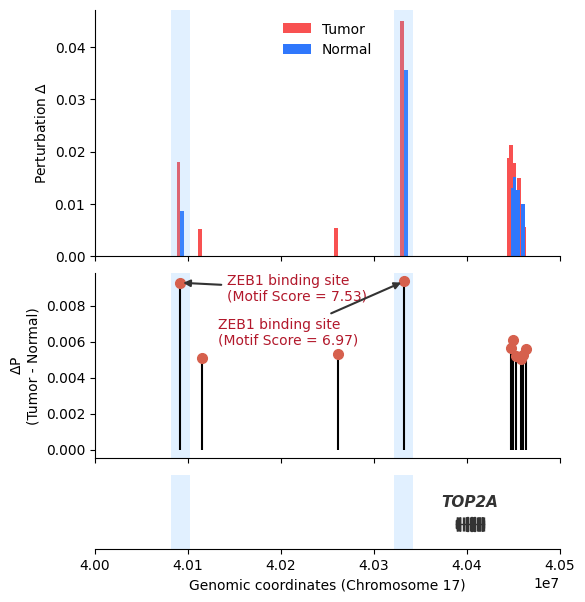

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def parse_gencode_gtf(gtf_path, target_gene):
    """
    Parses a large GTF file line by line to extract the coordinates of CDS, UTR, and exons for a specific target gene.
    
    Returns: 
        gene_start (int): The overall starting coordinate of the gene.
        gene_end (int): The overall ending coordinate of the gene.
        elements (dict): A dictionary containing lists of (start, end) tuples for CDS, UTR, and exon features.
    """
    # Dictionary to store the genomic coordinates (start, end) for specific structural features
    elements = {'CDS': [], 'UTR': [], 'exon': []}
    
    # Initialize overall gene boundaries to find the minimum start and maximum end positions
    gene_start, gene_end = float('inf'), 0
    
    print(f"Scanning GTF file, extracting {target_gene} ...")
    
    with open(gtf_path, 'r') as f:
        for line in f:
            # Skip header or comment lines
            if line.startswith('#'):
                continue
            
            # Fast pre-filter: skip lines that don't contain the target gene string at all
            if target_gene not in line:
                continue
                
            # GTF format is tab-separated; ensure the line has all 9 standard columns
            parts = line.strip().split('\t')
            if len(parts) < 9:
                continue
                
            feature_type = parts[2]
            attributes = parts[8]
            
            # Require an exact match for the gene name to avoid partial string matches 
            # (e.g., preventing a match for "GENE10" when looking for "GENE1")
            if f'gene_name "{target_gene}"' in attributes:
                start, end = int(parts[3]), int(parts[4])
                
                # Expand the overall genomic span of the gene if necessary
                gene_start = min(gene_start, start)
                gene_end = max(gene_end, end)
                
                # If the current feature is one of our target elements (CDS, UTR, exon), save its coordinates
                if feature_type in elements:
                    elements[feature_type].append((start, end))
                    
    print(f"Found {target_gene} spanning from {gene_start} to {gene_end}")
    
    return gene_start, gene_end, elements

# ==========================================
# Load data
# ==========================================
data = {
    'peak': ['chr17-40331043-40333077', 'chr17-40090995-40092546', 'chr17-40448545-40449433', 'chr17-40446642-40447744', 'chr17-40463057-40463688', 'chr17-40260482-40261809', 'chr17-40459431-40460217', 'chr17-40451992-40453435', 'chr17-40114497-40115147', 'chr17-40457762-40458554'], 
    'Normal': [0.035498, 0.008661, 0.015137, 0.013087, 0.000000, 0.000000, 0.000000, 0.012632, 0.000000, 0.009906], 
    'Tumor': [0.044838, 0.017932, 0.021234, 0.018715, 0.005569, 0.005315, 0.005239, 0.017809, 0.005107, 0.014938], 
    'delta_diff': [0.009340, 0.009270, 0.006097, 0.005627, 0.005569, 0.005315, 0.005239, 0.005177, 0.005107, 0.005031]
}
df = pd.DataFrame(data)

# Analytical coordinates
df[['chr', 'start', 'end']] = df['peak'].str.split('-', expand=True)
df['start'] = df['start'].astype(int)
df['end'] = df['end'].astype(int)
df['midpoint'] = (df['start'] + df['end']) / 2 

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6, 7), sharex=True, 
                                    gridspec_kw={'height_ratios': [2, 1.5, 0.6]})
plt.subplots_adjust(hspace=0.1)

# X axis range
x_min, x_max = 40000000, 40500000

# ==========================================
# Track 1: Tumor vs Normal
# ==========================================
width = 4000 # 
ax1.bar(df['midpoint'] - width/2, df['Tumor'], width=width, color='#f85151', label='Tumor')
ax1.bar(df['midpoint'] + width/2, df['Normal'], width=width, color='#2f77fc', label='Normal')

ax1.set_ylabel('Perturbation $\Delta$')
ax1.legend(loc='upper center', frameon=False)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ==========================================
# Track 2: Delta P
# ==========================================
markerline, stemlines, baseline = ax2.stem(df['midpoint'], df['delta_diff'], basefmt=" ")
plt.setp(stemlines, 'color', 'black', 'linewidth', 1.5)
plt.setp(markerline, 'color', '#D6604D', 'markersize', 7)
ax2.set_ylabel('$\Delta$P\n(Tumor - Normal)')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ==========================================
# Track 3: Marker Gene TOP2A
# ==========================================

gtf_file_path = "/path/gencode.v47.annotation.gtf" 
target_gene = "TOP2A"

gene_start, gene_end, elements = parse_gencode_gtf(gtf_file_path, target_gene)

if gene_start is not None and gene_end > 0:
    # 1. Intron
    ax3.plot([gene_start, gene_end], [0, 0], color='#333333', linewidth=1.0, zorder=1)
    
    # 2. UTR region
    for start, end in elements['UTR']:
        rect = patches.Rectangle((start, -0.15), end - start, 0.3, color='#333333', zorder=2)
        ax3.add_patch(rect)
        
    # 3. CDS region
    for start, end in elements['CDS']:
        rect = patches.Rectangle((start, -0.3), end - start, 0.6, color='#333333', zorder=3)
        ax3.add_patch(rect)
        
    if not elements['CDS'] and not elements['UTR']:
        for start, end in elements['exon']:
            rect = patches.Rectangle((start, -0.3), end - start, 0.6, color='#333333', zorder=2)
            ax3.add_patch(rect)

# gene name annotation
ax3.text((gene_start + gene_end)/2, 0.6, 'TOP2A', ha='center', va='bottom', 
         fontsize=11, fontstyle='italic', fontweight='bold', color='#333333')

ax3.set_ylim(-1, 2)
ax3.set_xlabel('Genomic coordinates (Chromosome 17)')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.set_yticks([])

# ==========================================
# highlight cross all axis
# ==========================================
    
tf_bindings = [
    {'peak': 'chr17-40090995-40092546', 'tf': 'ZEB1', 'score': 7.53},
    {'peak': 'chr17-40331043-40333077', 'tf': 'ZEB1', 'score': 6.97},
]

for idx, b in enumerate(tf_bindings):
    row = df[df['peak'] == b['peak']]
    if not row.empty:
        mid = row['midpoint'].values[0]
        for ax in [ax1, ax2, ax3]:
            ax.add_patch(patches.Rectangle((mid - 10000, -100), 20000, 200, 
                                           facecolor='#6DB8FF', alpha=0.2))
            
        if idx == 0:
            xt = mid+50000
            yt = row['delta_diff'].values[0]-0.001
        else:
            xt = mid-200000
            yt = row['delta_diff'].values[0]-0.0035

        ax2.annotate(f"{b['tf']} binding site\n(Motif Score = {b['score']})", 
                    xy=(mid, row['delta_diff'].values[0]),
                    xytext=(xt, yt),
                    arrowprops=dict(facecolor='black', arrowstyle='-|>', lw=1.5, color='#333333'),
                    fontsize=10, color='#B2182B')

offset_text = ax3.xaxis.get_offset_text()
offset_text.set_position((1.0, -0.1))
ax3.set_xlim(x_min, x_max)
plt.grid(False)
plt.savefig("/path/perturbation_tumor/gene_peak_figs/pancreas_TOP2A_ZEB1_motif_peak_region.pdf", dpi=300, bbox_inches='tight')
plt.show()

### gene: FMNL2, tf: LEF1, tissue: skin

scanf GTF file, extract FMNL2 ...
FMNL2 between 152335174 and 152649826


/tmp/ipykernel_3512189/4033902394.py:141: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax2.annotate('LEF1 binding site\n(Motif Score = 8.31)',


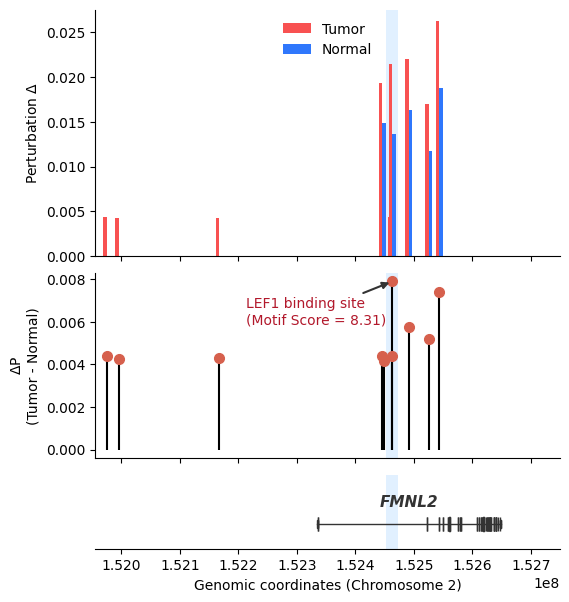

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def parse_gencode_gtf(gtf_path, target_gene):
    """
    Parses a large GTF file line by line to extract the coordinates of CDS, UTR, and exons for a specific target gene.
    
    Returns: 
        gene_start (int): The overall starting coordinate of the gene.
        gene_end (int): The overall ending coordinate of the gene.
        elements (dict): A dictionary containing lists of (start, end) tuples for CDS, UTR, and exon features.
    """
    # Dictionary to store the genomic coordinates (start, end) for specific structural features
    elements = {'CDS': [], 'UTR': [], 'exon': []}
    
    # Initialize overall gene boundaries to find the minimum start and maximum end positions
    gene_start, gene_end = float('inf'), 0
    
    print(f"Scanning GTF file, extracting {target_gene} ...")
    
    with open(gtf_path, 'r') as f:
        for line in f:
            # Skip header or comment lines
            if line.startswith('#'):
                continue
            
            # Fast pre-filter: skip lines that don't contain the target gene string at all
            if target_gene not in line:
                continue
                
            # GTF format is tab-separated; ensure the line has all 9 standard columns
            parts = line.strip().split('\t')
            if len(parts) < 9:
                continue
                
            feature_type = parts[2]
            attributes = parts[8]
            
            # Require an exact match for the gene name to avoid partial string matches 
            # (e.g., preventing a match for "GENE10" when looking for "GENE1")
            if f'gene_name "{target_gene}"' in attributes:
                start, end = int(parts[3]), int(parts[4])
                
                # Expand the overall genomic span of the gene if necessary
                gene_start = min(gene_start, start)
                gene_end = max(gene_end, end)
                
                # If the current feature is one of our target elements (CDS, UTR, exon), save its coordinates
                if feature_type in elements:
                    elements[feature_type].append((start, end))
                    
    print(f"Found {target_gene} spanning from {gene_start} to {gene_end}")
    
    return gene_start, gene_end, elements

# ==========================================
# Load data
# ==========================================
data = {
    'peak': ['chr2-152462593-152463182', 'chr2-152542367-152543838', 'chr2-152490694-152491974', 'chr2-152524726-152525966', 'chr2-151974889-151975833', 'chr2-152462211-152462429', 'chr2-152445329-152446537', 'chr2-152167084-152167867', 'chr2-151995127-151996156', 'chr2-152449452-152449739'], 
    'Normal': [0.013581, 0.018786, 0.016260, 0.011791, 0.000000, 0.000000, 0.014904, 0.000000, 0.000000, 0.000000], 
    'Tumor': [0.021479, 0.026184, 0.022035, 0.016962, 0.004393, 0.004385, 0.019276, 0.004280, 0.004236, 0.004168], 
    'delta_diff': [0.007898, 0.007398, 0.005775, 0.005171, 0.004393, 0.004385, 0.004373, 0.004280, 0.004236, 0.004168]
}
df = pd.DataFrame(data)

# Analytical coordinates
df[['chr', 'start', 'end']] = df['peak'].str.split('-', expand=True)
df['start'] = df['start'].astype(int)
df['end'] = df['end'].astype(int)
df['midpoint'] = (df['start'] + df['end']) / 2 

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6, 7), sharex=True, 
                                    gridspec_kw={'height_ratios': [2, 1.5, 0.6]})
plt.subplots_adjust(hspace=0.1)

# X axis range
x_min, x_max = df['start'].min()-20000, df['end'].max()+20000

# ==========================================
# Track 1: Tumor vs Normal
# ==========================================
width = 6000 # 
ax1.bar(df['midpoint'] - width/2, df['Tumor'], width=width, color='#f85151', label='Tumor')
ax1.bar(df['midpoint'] + width/2, df['Normal'], width=width, color='#2f77fc', label='Normal')

ax1.set_ylabel('Perturbation $\Delta$')
ax1.legend(loc='upper center', frameon=False)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ==========================================
# Track 2: Delta P
# ==========================================
markerline, stemlines, baseline = ax2.stem(df['midpoint'], df['delta_diff'], basefmt=" ")
plt.setp(stemlines, 'color', 'black', 'linewidth', 1.5)
plt.setp(markerline, 'color', '#D6604D', 'markersize', 7)
ax2.set_ylabel('$\Delta$P\n(Tumor - Normal)')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ==========================================
# Track 3: Marker Gene FMNL2
# ==========================================

gtf_file_path = "/path/gencode.v47.annotation.gtf" 
target_gene = "FMNL2"

gene_start, gene_end, elements = parse_gencode_gtf(gtf_file_path, target_gene)

if gene_start is not None and gene_end > 0:
    # 1. Intron
    ax3.plot([gene_start, gene_end], [0, 0], color='#333333', linewidth=1.0, zorder=1)
    
    # 2. UTR region
    for start, end in elements['UTR']:
        rect = patches.Rectangle((start, -0.15), end - start, 0.3, color='#333333', zorder=2)
        ax3.add_patch(rect)
        
    # 3. CDS region
    for start, end in elements['CDS']:
        rect = patches.Rectangle((start, -0.3), end - start, 0.6, color='#333333', zorder=3)
        ax3.add_patch(rect)
        
    if not elements['CDS'] and not elements['UTR']:
        for start, end in elements['exon']:
            rect = patches.Rectangle((start, -0.3), end - start, 0.6, color='#333333', zorder=2)
            ax3.add_patch(rect)

# gene name annotation
ax3.text((gene_start + gene_end)/2, 0.6, target_gene, ha='center', va='bottom', 
         fontsize=11, fontstyle='italic', fontweight='bold', color='#333333')

ax3.set_ylim(-1, 2)
ax3.set_xlabel('Genomic coordinates (Chromosome 2)')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.set_yticks([])

# ==========================================
# highlight cross all axis
# ==========================================

highlight_mid = df[df['peak'] == 'chr2-152462593-152463182']['midpoint'].values[0]
for ax in [ax1, ax2, ax3]:
    rect = patches.Rectangle((highlight_mid - 10000, ax.get_ylim()[0]*2), 20000, ax.get_ylim()[1]*3, 
                             linewidth=0, edgecolor='none', facecolor="#6DB8FF", alpha=0.2, zorder=0)
    ax.add_patch(rect)

yt = df[df['peak'] == 'chr2-152462593-152463182']['delta_diff'].values[0]
ax2.annotate('LEF1 binding site\n(Motif Score = 8.31)', 
             xy=(highlight_mid, yt),
             xytext=(highlight_mid - 250000, yt-0.002),
             arrowprops=dict(facecolor='black', arrowstyle='-|>', lw=1.5, color='#333333'),
             fontsize=10, color='#B2182B')

offset_text = ax3.xaxis.get_offset_text()
offset_text.set_position((1.0, -0.1))
x_max = gene_end + 100000
ax3.set_xlim(x_min, x_max)
plt.grid(False)
plt.savefig("/path/perturbation_tumor/gene_peak_figs/skin_FMNL2_LEF1_motif_peak_region.pdf", dpi=300, bbox_inches='tight')
plt.show()